In [11]:
import pandas as pd

df = pd.read_csv("../data/raw/matches.csv")
print(df.shape)
print(df.columns.tolist())
df.head()


(104, 42)
['round', 'gameweek', 'dayofweek', 'date', 'start_time', 'home_team', 'away_team', 'score', 'home_score', 'away_score', 'attendance', 'venue', 'referee', 'home_formation', 'away_formation', 'home_manager', 'away_manager', 'home_captain', 'away_captain', 'home_possession', 'away_possession', 'home_sot', 'away_sot', 'home_total_shots', 'away_total_shots', 'home_saves', 'away_saves', 'home_cards_yellow', 'away_cards_yellow', 'home_cards_red', 'away_cards_red', 'home_fouls', 'away_fouls', 'home_corners', 'away_corners', 'home_crosses', 'away_crosses', 'home_interceptions', 'away_interceptions', 'home_offsides', 'away_offsides', 'notes']


,round,gameweek,dayofweek,date,start_time,home_team,away_team,score,home_score,away_score,...,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides,notes
0,Group stage,1.0,Thu,2026-06-11,13:00,Mexico,South Africa,2–0,2.0,0.0,...,11,3,1,12,8,8,7,1.0,1.0,NaN
1,Group stage,1.0,Thu,2026-06-11,20:00,Korea Republic,Czechia,2–1,2.0,1.0,...,16,4,5,12,15,11,7,2.0,2.0,NaN
2,Group stage,1.0,Fri,2026-06-12,15:00,Canada,Bosnia–Herz,1–1,1.0,1.0,...,20,9,4,24,10,4,10,1.0,0.0,NaN
3,Group stage,1.0,Fri,2026-06-12,18:00,United States,Paraguay,4–1,4.0,1.0,...,17,3,1,17,5,11,9,2.0,1.0,NaN
4,Group stage,1.0,Sat,2026-06-13,12:00,Qatar,Switzerland,1–1,1.0,1.0,...,11,3,10,8,35,10,7,0.0,1.0,NaN


In [12]:
print(df[["home_corners", "away_corners"]].isna().sum())


home_corners    0
away_corners    0
dtype: int64


In [13]:
# Reshape home rows
home = df[["round", "gameweek", "date", "home_team", "away_team", "home_corners"]].copy()
home.columns = ["round", "gameweek", "date", "team", "opponent", "corners"]

# Reshape away rows
away = df[["round", "gameweek", "date", "away_team", "home_team", "away_corners"]].copy()
away.columns = ["round", "gameweek", "date", "team", "opponent", "corners"]

# Combine into one long table
team_matches = pd.concat([home, away], ignore_index=True)
print(team_matches.shape)
team_matches.head()


(208, 6)


,round,gameweek,date,team,opponent,corners
0,Group stage,1.0,2026-06-11,Mexico,South Africa,3
1,Group stage,1.0,2026-06-11,Korea Republic,Czechia,4
2,Group stage,1.0,2026-06-12,Canada,Bosnia–Herz,9
3,Group stage,1.0,2026-06-12,United States,Paraguay,3
4,Group stage,1.0,2026-06-13,Qatar,Switzerland,3


In [14]:
host_nations = ["United States", "Mexico", "Canada"]

host_corners = team_matches.loc[team_matches["team"].isin(host_nations), "corners"]
overall_mean_corners = team_matches["corners"].mean()

print("Host nation team-match rows:", len(host_corners))
print(host_corners.describe())
print(f"\nOverall tournament mean corners (benchmark): {overall_mean_corners:.2f}")

Host nation team-match rows: 15
count    15.000000
mean      6.333333
std       5.023753
min       0.000000
25%       3.000000
50%       4.000000
75%       9.000000
max      19.000000
Name: corners, dtype: float64

Overall tournament mean corners (benchmark): 4.57


In [15]:
# Population is small (n=15), so we use it directly as our sample (census)
sample_host_corners = host_corners.copy()

print(f"Sample size: {len(sample_host_corners)}")
print(sample_host_corners.describe())


Sample size: 15
count    15.000000
mean      6.333333
std       5.023753
min       0.000000
25%       3.000000
50%       4.000000
75%       9.000000
max      19.000000
Name: corners, dtype: float64


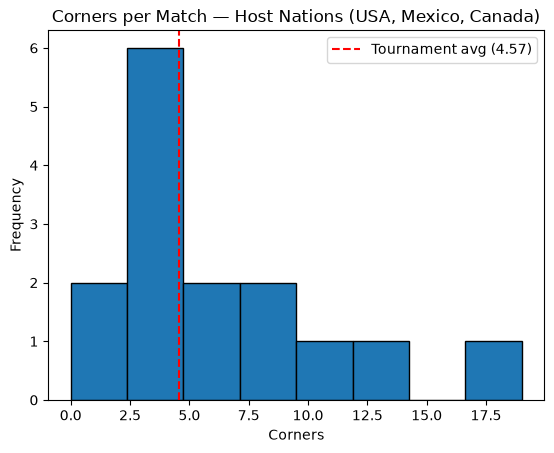

In [16]:
import matplotlib.pyplot as plt

plt.hist(sample_host_corners, bins=8, edgecolor="black")
plt.axvline(overall_mean_corners, color="red", linestyle="--", label=f"Tournament avg ({overall_mean_corners:.2f})")
plt.title("Corners per Match — Host Nations (USA, Mexico, Canada)")
plt.xlabel("Corners")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("../outputs/figures/abhi_corners_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
from scipy import stats

mean_host = sample_host_corners.mean()
sem_host = stats.sem(sample_host_corners)
ci_host = stats.t.interval(confidence=0.95, df=len(sample_host_corners)-1, loc=mean_host, scale=sem_host)

print(f"Host nations — mean corners: {mean_host:.2f}")
print(f"95% CI: ({ci_host[0]:.2f}, {ci_host[1]:.2f})")
print(f"Tournament-wide benchmark: {overall_mean_corners:.2f}")

Host nations — mean corners: 6.33
95% CI: (3.55, 9.12)
Tournament-wide benchmark: 4.57


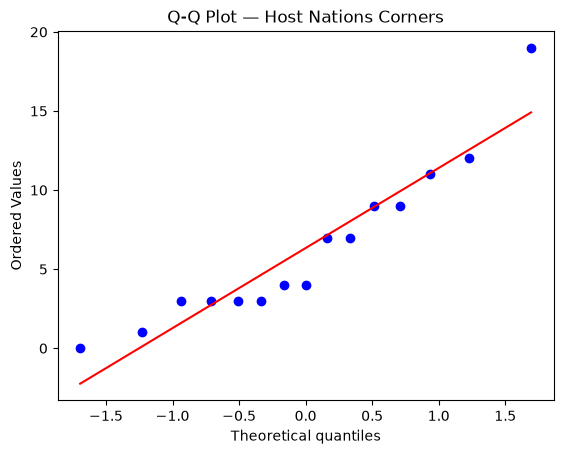

In [18]:
plt.figure()
stats.probplot(sample_host_corners, dist="norm", plot=plt)
plt.title("Q-Q Plot — Host Nations Corners")
plt.savefig("../outputs/figures/abhi_corners_qqplot.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# H0: mean corners (Host nations) = tournament-wide average
# H1: mean corners (Host nations) ≠ tournament-wide average

t_stat, p_value = stats.ttest_1samp(sample_host_corners, popmean=overall_mean_corners)

print(f"t-statistic = {t_stat:.3f}")
print(f"p-value = {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject H0 — host nations won significantly more corners than the tournament average.")
else:
    print("\nResult: Fail to reject H0 — no statistically significant difference")
    print("between host-nation corners and the tournament-wide average.")

t-statistic = 1.358
p-value = 0.19602

Result: Fail to reject H0 — no statistically significant difference
between host-nation corners and the tournament-wide average.


### Note on limitations
The host-nation sample is small (n=15), and the Q-Q plot shows a departure from 
normality driven by one high-corner match (19 corners). This violates the normality 
assumption somewhat, and combined with the small sample size, limits the statistical 
power to detect a true difference — even though the descriptive means differ 
meaningfully (6.33 vs 4.57), the test could not confirm this is not due to chance.